In [1]:
import os
import sys

sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import uproot
import awkward as ak
import collections
from particle import Particle
import seaborn as sns

# Import our modules
from data_utils import (
    load_root_file
)

# Set matplotlib style
plt.style.use("hep.mplstyle")

# Check TensorFlow version and GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_DIR = "../datasets"

file_list = [
    "Zbb.root",
    "Zcc.root",
    "Zss.root",
    "Zud.root"
]

TensorFlow version: 2.18.0
GPU available: []


In [2]:
events = load_root_file(f"{DATA_DIR}/{file_list[0]}")

## Thrust

In [3]:


thrust_x = ak.to_numpy(events["Thrust_x"])
thrust_y = ak.to_numpy(events["Thrust_y"])
thrust_z = ak.to_numpy(events["Thrust_z"])

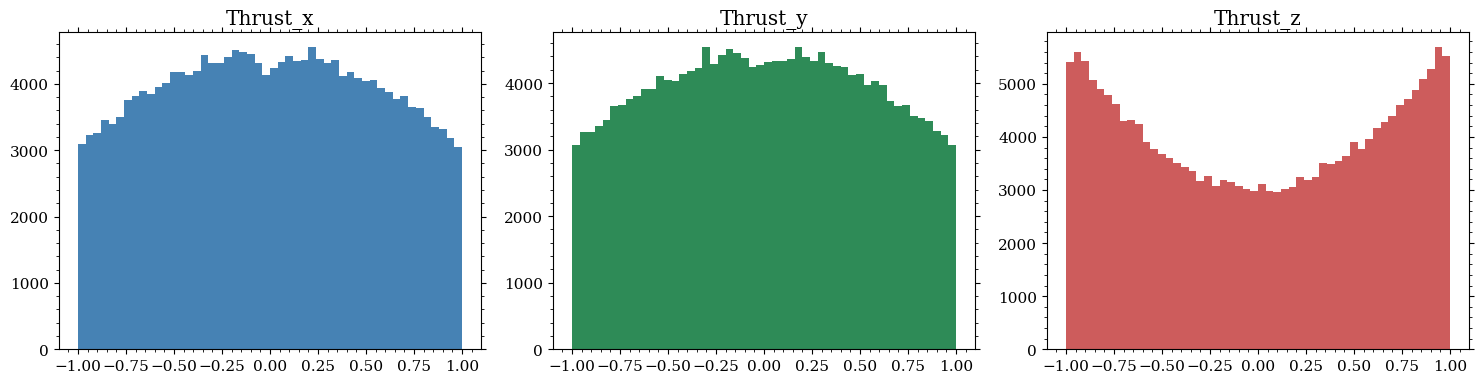

In [4]:
# Plot histograms
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(thrust_x, bins=50, color='steelblue')
plt.title("Thrust_x")

plt.subplot(1, 3, 2)
plt.hist(thrust_y, bins=50, color='seagreen')
plt.title("Thrust_y")

plt.subplot(1, 3, 3)
plt.hist(thrust_z, bins=50, color='indianred')
plt.title("Thrust_z")

plt.tight_layout()
plt.show()

## Particle

In [8]:
# Particle ID distribution
particle_ids = ak.flatten(events["Particle_ID"])
pid_counts = collections.Counter(particle_ids.tolist())

def get_particle_name(pdg_id):
    try:
        return Particle.from_pdgid(pdg_id).name
    except Exception:
        return "unknown"

for pid, count in pid_counts.items():
    name = get_particle_name(pid)
    print(f"PDG ID {pid:>6} ({name:>20}): {count}")

PDG ID     11 (                  e-): 61754
PDG ID   2112 (                   n): 81873
PDG ID  -2112 (                  n~): 81774
PDG ID    211 (                 pi+): 1682062
PDG ID   -211 (                 pi-): 1682119
PDG ID    130 (               K(L)0): 246663
PDG ID     22 (               gamma): 4696548
PDG ID   -321 (                  K-): 270157
PDG ID  -2212 (                  p~): 89489
PDG ID    -11 (                  e+): 61500
PDG ID    -13 (                 mu+): 43848
PDG ID   2212 (                   p): 89363
PDG ID     13 (                 mu-): 44101
PDG ID    321 (                  K+): 270822
PDG ID      0 (             unknown): 76


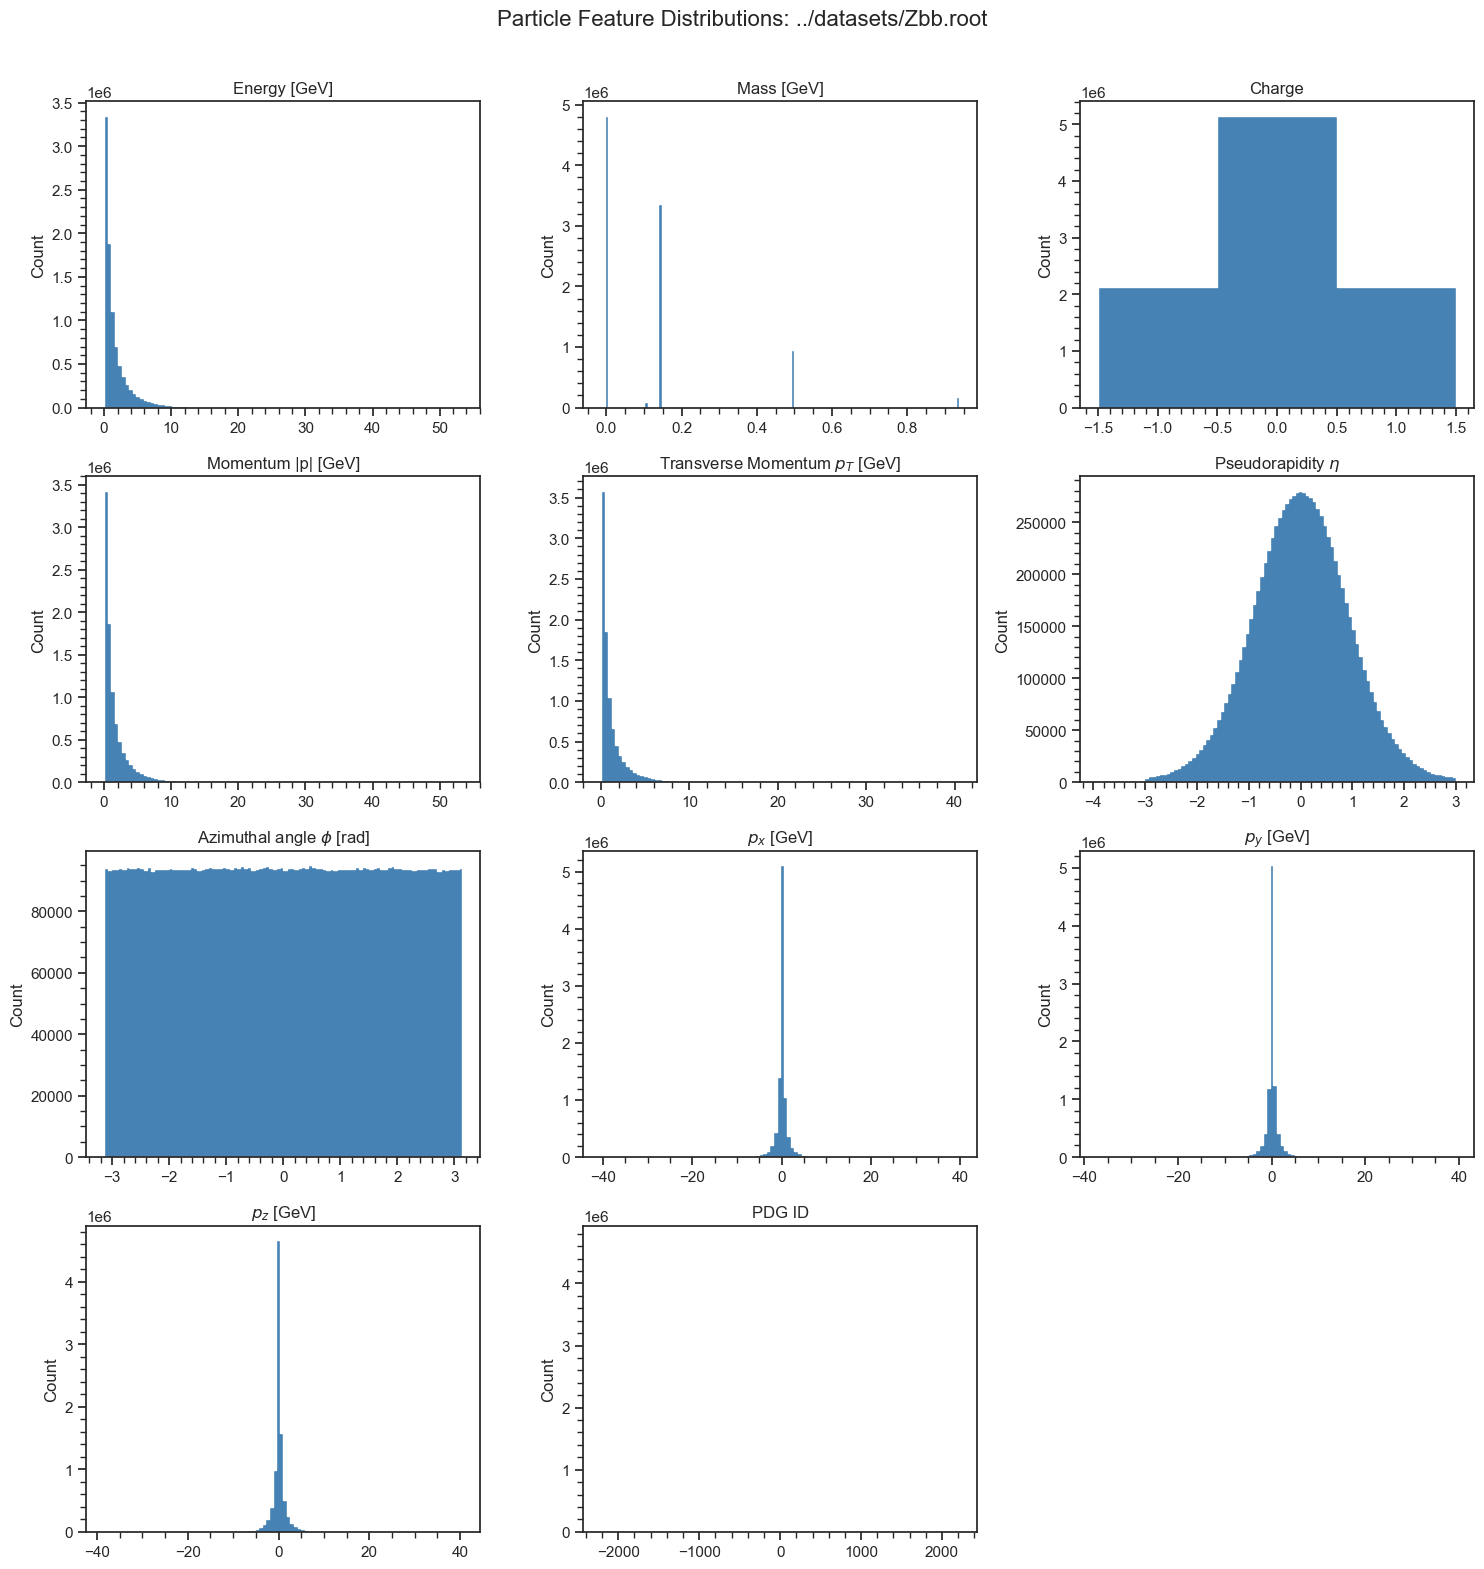

In [10]:
def plot_particle_feature_distributions(filepath):
    """
    Load particle-level variables from a ROOT file and plot their 1D distributions.

    Parameters:
        filepath (str): Path to the input ROOT file (e.g., "Zbb.root").
    """
    # Open the ROOT file and read particle-level variables
    tree = uproot.open(f"{filepath}:events")
    arrays = tree.arrays(filter_name=[
        "Particle_ID", "Particle_m", "Particle_e", "Particle_q",
        "Particle_p", "Particle_pt", "Particle_px", "Particle_py", "Particle_pz",
        "Particle_eta", "Particle_phi"
    ], library="ak")

    # Flatten arrays to make them plottable (from jagged to 1D)
    flat_data = {key: ak.flatten(arrays[key]) for key in arrays.fields}

    # Define human-readable labels for plots
    label_map = {
        "Particle_ID": "PDG ID",
        "Particle_m": "Mass [GeV]",
        "Particle_e": "Energy [GeV]",
        "Particle_q": "Charge",
        "Particle_p": "Momentum |p| [GeV]",
        "Particle_pt": "Transverse Momentum $p_T$ [GeV]",
        "Particle_px": "$p_x$ [GeV]",
        "Particle_py": "$p_y$ [GeV]",
        "Particle_pz": "$p_z$ [GeV]",
        "Particle_eta": "Pseudorapidity $\eta$",
        "Particle_phi": "Azimuthal angle $\phi$ [rad]"
    }

    # Determine grid layout for subplots
    n_features = len(flat_data)
    ncols = 3
    nrows = int(np.ceil(n_features / ncols))

    # Create figure and subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    # Plot each feature in a subplot
    for i, (key, values) in enumerate(flat_data.items()):
        ax = axes[i]
        if "ID" in key or "q" in key:
            # Plot discrete histogram
            bins = np.arange(min(values), max(values) + 1.5) - 0.5
            ax.hist(values, bins=bins, histtype='stepfilled', color='steelblue')
        else:
            # Plot continuous histogram
            ax.hist(values, bins=100, histtype='stepfilled', color='steelblue')

        ax.set_title(label_map.get(key, key), fontsize=12)
        ax.set_xlabel("")
        ax.set_ylabel("Count")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Particle Feature Distributions: {filepath}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_particle_feature_distributions(f"{DATA_DIR}/Zbb.root")
# -> We can safely pad particle features with -999
# Standardise e, p, pt, eta, phi